# LAB 07.01 - Optimization for ML

<a target="_blank" href="https://colab.research.google.com/github/rramosp/ai4eng.v1/blob/main/content/LAB%2007.01%20-%20OPTIMIZATION%20FOR%20ML.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()


replicating local resources


In [2]:
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L07.01", varname="student");

logging in as rene.arenas@udea.edu.co... please wait

-------------
using course session ai4eng.v1.udea.r4::2026.1
success!! you are logged in
-------------


In [3]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from local.lib import mlutils
%matplotlib inline

/content/local/lib/mlutils.py:445: SyntaxWarning: invalid escape sequence '\m'
  time_str = "fit time  (TRAIN)    %.2f $\mu$secs"%(fitting_time*1000)


## Dataset

you have data in a matrix $\mathbf{X} \in \mathbb{R}^{m\times n}$ and the corresponding labels $\mathbf{y} \in \mathbb{R}^m$.

each row in matrix $\mathbf{X}$ contains one data point $\mathbf{x}^{(i)}$

$$\begin{bmatrix}
 x^{(0)}\\
 x^{(1)}\\
 ... \\
 x^{(m-1)}
\end{bmatrix}
$$

and each data point is a vector $\mathbf{x}^{(i)}=[x^{(i)}_0, x^{(i)}_1,...,x^{(i)}_{n-1}]$.

Also, each data point has an associated label $\mathbf{y} = [y^{(0)}, y^{(1)},..., y^{(m-1)}]$.

We will be doing **binary classification** so $y^{(0)}\in \{0,1\}$

In [4]:

d = pd.read_csv("local/data/moons.csv")
X = d[["col1", "col2"]].values
y = d["target"].values
print ("m=%d\nn=%d"%(X.shape[0], X.shape[1]))
X.shape, y.shape


m=200
n=2


((200, 2), (200,))

In [5]:

print (X[:10])
print (y[:10])


[[ 1.303374   -0.81478084]
 [-0.98727894 -0.06456482]
 [ 2.317555    0.44925394]
 [ 0.85310268 -0.22083508]
 [-0.97006406  0.64095693]
 [ 1.65849049 -0.2342485 ]
 [ 0.8684624  -0.28940167]
 [ 0.05631143  0.00296565]
 [ 0.88824669 -0.12888889]
 [ 0.9925954   0.31451716]]
[1 0 1 1 0 1 1 1 1 0]


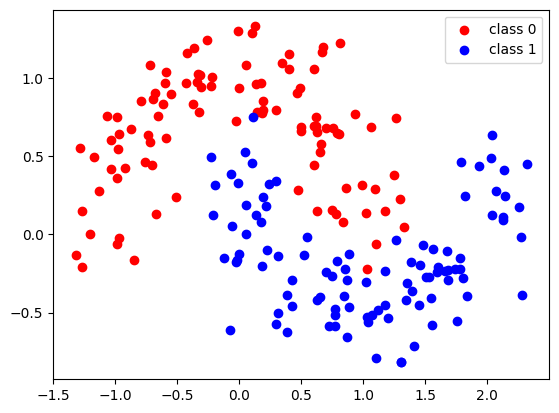

In [6]:

plt.scatter(X[:,0][y==0], X[:,1][y==0], color="red", label="class 0")
plt.scatter(X[:,0][y==1], X[:,1][y==1], color="blue", label="class 1")
plt.legend();


## Task 1: Create a prediction function

**complete the following prediction function** which accepts:
    
- $\mathbf{\theta} = [\theta_0, \theta_1,... \theta_{n-1}] \in \mathbb{R}^n$, a `numpy` vector.
- $b  \in \mathbb{R}$ , a `float`.
- $\mathbf{X} \in \mathbb{R}^{m\times n}$, a `numpy` 2D array.

and returns

- $\hat{\mathbf{y}} = [\hat{y}^{(0)}, \hat{y}^{(1)}, ..., \hat{y}^{(m-1)}] \in \mathbb{R}^m$ defined as follows

$$\hat{y}^{(i)} = \text{sigm}(\mathbf{\theta} \cdot \mathbf{x}^{(i)} + b) = \text{sigm}(\theta_0 x^{(i)}_0 + \theta_1 x^{(i)}_1 + b)$$

with

$$\text{sigm}(z) = \frac{1}{1+e^{-z}}$$

note that we can also express the prediction vector $\hat{\mathbf{y}}$ over the whole dataset as

$$\hat{\mathbf{y}} = \text{sigm}(\mathbf{\theta} \cdot \mathbf{X} + b)$$

observe that for any $z$, the sigmoid function squeshes its value between 0 and 1. It can  be simply seen as a continuous **step** function which converts any negative value into 0, and any positive value into 1.

**challenge**: use only one line of python code (not counting the $\text{sigm}$ definition)

**warn**: your function must work with any $\mathbf{X} \in \mathbb{R}^{m\times n}$ and  $\mathbf{\theta} \in \mathbb{R}^n$, for any $m$ and $n$, not only for $n=2$

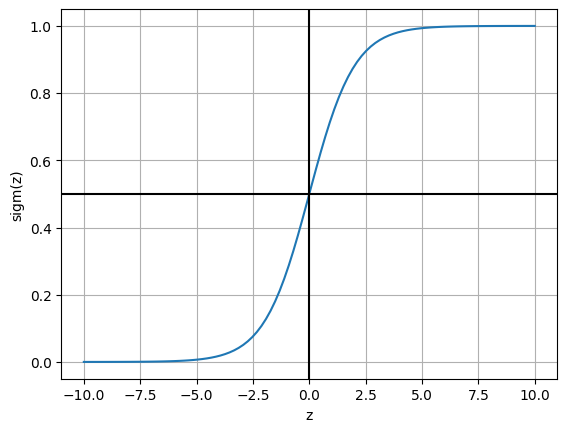

In [7]:

z = np.linspace(-10,10,100)
sigm = lambda x: 1/(1+np.exp(-x))
plt.plot(z, sigm(z)); plt.grid(); plt.xlabel("z"); plt.ylabel("sigm(z)")
plt.axhline(0.5, color="black"); plt.axvline(0, color="black")


In [8]:
def prediction(t, b, X):
    sigm = lambda z: 1 / (1 + np.exp(-z))
    return sigm(X @ t + b)


check manually your code. The following should yield a vector with 200 elements, whose sum should be 99.97 at its four first elements

    [0.02328672 0.91257015 0.03781132 0.16139629 ... ]

In [9]:
t,b = np.r_[[-2,2]], 0.5
yhat = prediction(t,b,X)
print (yhat.shape)
print (np.sum(yhat))
print (yhat)

(200,)
99.97386377320545
[0.02328672 0.91257015 0.03781132 0.16139629 0.97638655 0.03607275
 0.13994725 0.59707888 0.17736962 0.29814299 0.65755661 0.1771665
 0.10336722 0.36797186 0.04604533 0.09808586 0.56288781 0.13838998
 0.85687064 0.05004791 0.02243482 0.10694533 0.66303597 0.05995927
 0.5648827  0.03165357 0.17804726 0.98365697 0.08950736 0.17469931
 0.03471958 0.93813354 0.05558113 0.6827537  0.10439341 0.0357004
 0.19535612 0.97352349 0.58294619 0.11848779 0.64419508 0.94637233
 0.4612505  0.96468022 0.1091973  0.9605648  0.04208797 0.86259254
 0.02494794 0.8807287  0.24871015 0.94949941 0.97747638 0.06270446
 0.97809036 0.5477603  0.05661584 0.98141433 0.02484988 0.94894862
 0.58416607 0.76381496 0.36141804 0.84771584 0.16951545 0.88137323
 0.96772376 0.0273022  0.43314501 0.89612832 0.86652099 0.9318912
 0.66531857 0.98465757 0.01876907 0.0682854  0.91618647 0.96553816
 0.67409963 0.43668183 0.3977055  0.24321165 0.69574722 0.04491925
 0.1119693  0.02306961 0.04528634 0.1001

**submit your code**

In [10]:
student.submit_task(globals(), task_id="task_01");

## Task 2: Create the loss function

accepting the following paramters

- $\mathbf{\theta} = [\theta_0, \theta_1] \in \mathbb{R}^n$, a `numpy` vector.
- $b  \in \mathbb{R}$ , a `float`.
- $\mathbf{X} \in \mathbb{R}^{m\times n}$, a `numpy` 2D array.
- $\mathbf{y} \in \mathbb{R}^m$, a `numpy` vector.


$$\text{loss}(\theta, b, \mathbf{X} , \mathbf{y}) = \frac{1}{m}\sum_{i=0}^{m-1}(\hat{y}^{(i)}-y^{(i)})^2$$

**challenge**: use only one line of python (not counting the `sigm` and `prediction` functions).

In [11]:
def loss(t, b, X, y):
    sigm = lambda z: 1/(1+np.exp(-z))
    prediction = lambda t, b, X: sigm(np.dot(X, t) + b)
    return np.mean((prediction(t, b, X) - y) ** 2)


check manually your code, you should get a loss of 0.664 approx.

In [12]:
t,b = np.r_[[-2,2]], 0.5
loss(t,b,X,y)

np.float64(0.6640737783637011)

**submit your code**

In [13]:
student.submit_task(globals(), task_id="task_02");

## Task 3: Obtain the best $\theta$ and $b$ with black box optimization

Complete the following function so that it returns the best $\theta$ and $b$ for a given data set.

Observe that

- `x0` in `scipy.optimize.minimize` must be a vector of three items, the first two corresponding to $\theta_0$ and $\theta_1$, and the last one to $b$.
- the return value of the optimizer `r.x` will also contain three items, and you will have to separate the first two into `t` and the last one into `b`.
- you will have to adapt your `loss` function created before so that it extracts $\theta$ and $b$ from the variable `params`.

In [14]:
def fit(X, y):
    from scipy.optimize import minimize

    # La función de pérdida recibe un vector de parámetros
    def loss(params):
        t = params[:-1]        # Extrae theta (los primeros n)
        b = params[-1]         # Extrae b (el último)
        sigm = lambda z: 1/(1+np.exp(-z))
        yhat = sigm(np.dot(X, t) + b)
        return np.mean((yhat - y) ** 2)

    # Inicialización de parámetros (theta0, theta1, b)
    tinit = np.zeros(shape=X.shape[1] + 1)

    # Optimización
    r = minimize(loss, tinit)

    # Extraer theta y b
    t = r.x[:-1]
    b = r.x[-1]

    return t, b


In [15]:
t, b = fit(X,y)

check manually your code, you should get an accuracy of about 84%-87%, and a classification frontier similar to this one.

**Observe** how we convert the sigmoid output which can be any number $\in [0,1]$, into a discrete classification (0 or 1) by thresholding on 0.5

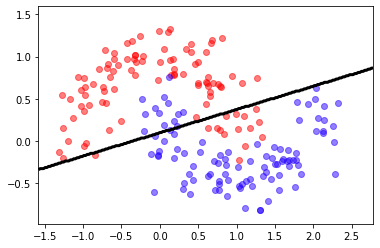

In [16]:

from IPython.display import Image
Image(filename='local/imgs/logregmoons.png')


In [17]:
t, b

(array([ 1.060626  , -3.83856858]), np.float64(0.36707481271628356))

(np.float64(0.517275), np.float64(0.482725))

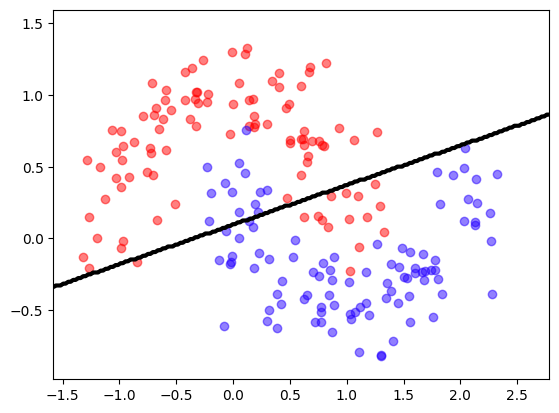

In [18]:
mlutils.plot_2Ddata_with_boundary(lambda X: prediction(t,b,X)>.5, X, y)

In [19]:
acc = np.mean( (prediction(t,b,X)>.5)==y)
print ("accuracy %.3f"%acc)

accuracy 0.860


**submit your code**

In [20]:
student.submit_task(globals(), task_id="task_03");